# Pneumonia Detection from Chest X-Rays

## 1. Imports and environment setup

In [1]:
from pathlib import Path
import os
import warnings
import random as rn
import glob

import cv2
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import tensorflow as tf
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPool2D
from keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
%matplotlib inline

## 2. Dataset loading and path configuration

In [ ]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebook" else CURRENT_DIR

DATASET_ROOT = PROJECT_ROOT / "data" / "chest_xray" / "chest_xray"
TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"



MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)
print("Train exists :", TRAIN_DIR.exists())
print("Validation exists :", VAL_DIR.exists())
print("Test exists :", TEST_DIR.exists())

Project root : C:\Users\user\Pneumonia_Detection
Dataset root : C:\Users\user\Pneumonia_Detection\data\chest_xray\chest_xray
Train exists : True
Validation exists : True
Test exists : True


In [7]:
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"\n{split_dir.name.upper()} directory:")
    if split_dir.exists():
        for class_dir in sorted(split_dir.iterdir()):
            if class_dir.is_dir():
                print(f"  - {class_dir.name}: {len(list(class_dir.glob('*')))} files")
    else:
        print("  Directory not found.")


TRAIN directory:
  - NORMAL: 1092 files
  - PNEUMONIA: 3876 files

VAL directory:
  - NORMAL: 9 files
  - PNEUMONIA: 9 files

TEST directory:
  - NORMAL: 234 files
  - PNEUMONIA: 250 files


In [8]:
base_dir = DATASET_ROOT

In [9]:
print(base_dir.exists())  # Vérifie si le dossier principal du dataset existe

True


In [10]:
def get_data(data_dir):
    images = []
    labels = []
    img_size = 128
    valid_extensions = {".jpg", ".jpeg", ".png"}

    for label in ["NORMAL", "PNEUMONIA"]:
        path = Path(data_dir) / label
        if not path.exists():
            print(f"Le répertoire {path} n'existe pas.")
            continue

        class_num = 0 if label == "NORMAL" else 1
        for img_path in path.iterdir():
            if img_path.suffix.lower() not in valid_extensions:
                continue

            try:
                img_arr = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img_arr is None:
                    print(f"Impossible de charger l'image {img_path.name}.")
                    continue

                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                images.append(resized_arr)
                labels.append(class_num)
            except Exception as e:
                print(f"Erreur lors du traitement de l'image {img_path.name}: {e}")

    return images, labels

train_images, train_labels = get_data(TRAIN_DIR)
test_images, test_labels = get_data(TEST_DIR)
val_images, val_labels = get_data(VAL_DIR)

In [11]:
print(f"Train set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")

Train set: 4966 images
Validation set: 16 images
Test set: 484 images


In [12]:
pneumonia_dir = TRAIN_DIR / "PNEUMONIA"
normal_dir = TRAIN_DIR / "NORMAL"

pneumonia = sorted([p.name for p in pneumonia_dir.iterdir() if p.is_file()])
normal = sorted([p.name for p in normal_dir.iterdir() if p.is_file()])

print(f"Nombre d'images de pneumonie : {len(pneumonia)}")
print(f"Nombre d'images normales : {len(normal)}")

Nombre d'images de pneumonie : 3876
Nombre d'images normales : 1092


## 3. Visualization and preprocessing

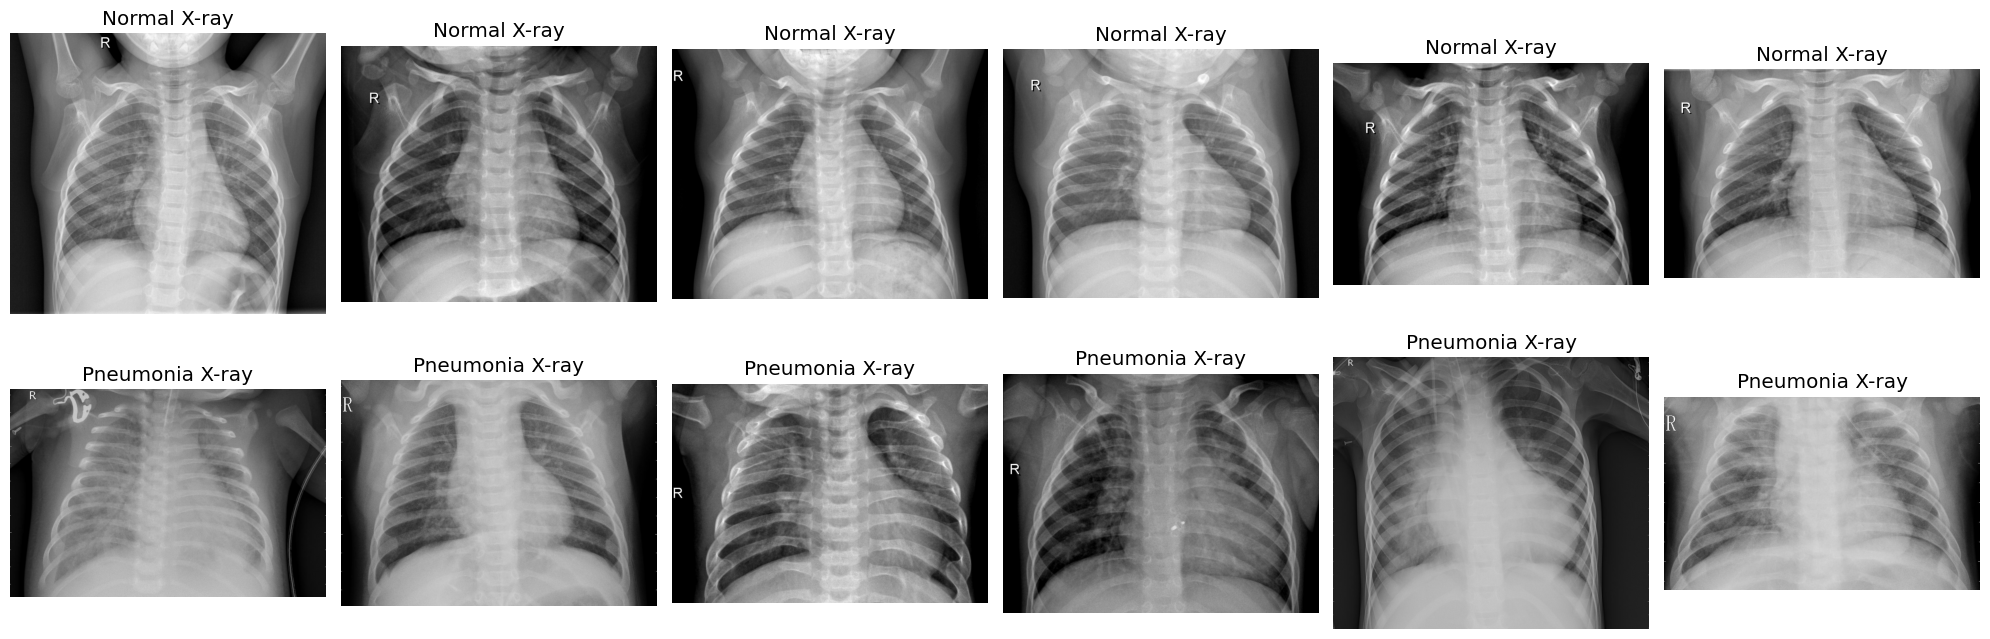

In [ ]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

normal_files = sorted([
    f for f in normal_dir.iterdir()
    if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
])

pneumonia_files = sorted([
    f for f in pneumonia_dir.iterdir()
    if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
])

plt.figure(figsize=(20, 10))

# Normal images
for i in range(6):
    plt.subplot(3, 6, i + 1)
    img = plt.imread(normal_files[i])
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Normal X-ray")

# Pneumonia images
for i in range(6):
    plt.subplot(3, 6, i + 7) 
    img = plt.imread(pneumonia_files[i])
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Pneumonia X-ray")

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# Fonction pour créer un DataFrame à partir des images et des étiquettes
def create_dataframe(images, labels, name):
    # Convertir les images en une liste de tableaux NumPy
    image_list = [img for img in images]

    # Créer un DataFrame
    df = pd.DataFrame({'image': image_list, 'label': labels})

    # Convertir les étiquettes en noms de classes
    df['label'] = df['label'].apply(lambda x: 'PNEUMONIA' if x == 1 else 'NORMAL')

    print(f"{name} DataFrame créé avec {len(df)} lignes.")
    return df

# Créer les DataFrames
train_df = create_dataframe(train_images, train_labels, "Train")
test_df = create_dataframe(test_images, test_labels, "Test")
val_df = create_dataframe(val_images, val_labels, "Validation")

# Afficher les premières lignes des DataFrames
print("\nTrain DataFrame:")
print(train_df.head())

print("\nTest DataFrame:")
print(test_df.head())

print("\nValidation DataFrame:")
print(val_df.head())

Train DataFrame créé avec 4966 lignes.
Test DataFrame créé avec 484 lignes.
Validation DataFrame créé avec 16 lignes.

Train DataFrame:
                                               image   label
0  [[22, 20, 16, 49, 60, 69, 74, 83, 90, 91, 96, ...  NORMAL
1  [[20, 26, 31, 35, 46, 45, 45, 53, 88, 90, 97, ...  NORMAL
2  [[0, 0, 17, 28, 37, 43, 54, 67, 71, 78, 82, 84...  NORMAL
3  [[42, 49, 55, 61, 71, 77, 78, 88, 90, 98, 101,...  NORMAL
4  [[82, 77, 54, 43, 28, 25, 22, 26, 26, 31, 33, ...  NORMAL

Test DataFrame:
                                               image   label
0  [[36, 32, 30, 30, 28, 28, 29, 28, 28, 30, 27, ...  NORMAL
1  [[38, 33, 27, 64, 87, 102, 124, 138, 136, 147,...  NORMAL
2  [[39, 37, 34, 39, 40, 36, 33, 34, 34, 31, 32, ...  NORMAL
3  [[77, 74, 75, 80, 101, 94, 89, 83, 107, 122, 1...  NORMAL
4  [[39, 43, 39, 38, 34, 32, 33, 35, 36, 30, 27, ...  NORMAL

Validation DataFrame:
                                               image   label
0  [[1, 11, 24, 34, 53, 66, 78,

In [17]:
train_df

,image,label
0,"[[22, 20, 16, 49, 60, 69, 74, 83, 90, 91, 96, ...",NORMAL
1,"[[20, 26, 31, 35, 46, 45, 45, 53, 88, 90, 97, ...",NORMAL
2,"[[0, 0, 17, 28, 37, 43, 54, 67, 71, 78, 82, 84...",NORMAL
3,"[[42, 49, 55, 61, 71, 77, 78, 88, 90, 98, 101,...",NORMAL
4,"[[82, 77, 54, 43, 28, 25, 22, 26, 26, 31, 33, ...",NORMAL
...,...,...
4961,"[[0, 0, 0, 0, 22, 34, 50, 56, 60, 69, 72, 80, ...",PNEUMONIA
4962,"[[91, 92, 97, 91, 88, 111, 111, 97, 79, 82, 83...",PNEUMONIA
4963,"[[27, 24, 11, 3, 0, 0, 0, 45, 46, 38, 48, 57, ...",PNEUMONIA
4964,"[[29, 42, 35, 37, 37, 59, 53, 47, 47, 45, 46, ...",PNEUMONIA


In [18]:
test_df

,image,label
0,"[[36, 32, 30, 30, 28, 28, 29, 28, 28, 30, 27, ...",NORMAL
1,"[[38, 33, 27, 64, 87, 102, 124, 138, 136, 147,...",NORMAL
2,"[[39, 37, 34, 39, 40, 36, 33, 34, 34, 31, 32, ...",NORMAL
3,"[[77, 74, 75, 80, 101, 94, 89, 83, 107, 122, 1...",NORMAL
4,"[[39, 43, 39, 38, 34, 32, 33, 35, 36, 30, 27, ...",NORMAL
...,...,...
479,"[[22, 47, 33, 46, 28, 207, 45, 200, 152, 30, 2...",PNEUMONIA
480,"[[145, 85, 69, 28, 27, 11, 12, 16, 18, 17, 18,...",PNEUMONIA
481,"[[22, 15, 10, 201, 198, 36, 6, 11, 10, 15, 30,...",PNEUMONIA
482,"[[213, 41, 56, 53, 57, 58, 58, 60, 49, 158, 60...",PNEUMONIA


In [19]:
val_df

,image,label
0,"[[1, 11, 24, 34, 53, 66, 78, 99, 109, 111, 111...",NORMAL
1,"[[2, 104, 91, 57, 4, 6, 6, 7, 2, 0, 0, 0, 1, 0...",NORMAL
2,"[[1, 78, 96, 104, 103, 116, 124, 128, 128, 135...",NORMAL
3,"[[1, 149, 62, 34, 33, 23, 27, 22, 17, 22, 15, ...",NORMAL
4,"[[2, 13, 17, 14, 34, 40, 45, 50, 58, 62, 62, 6...",NORMAL
5,"[[4, 251, 60, 64, 68, 146, 117, 110, 111, 118,...",NORMAL
6,"[[7, 30, 31, 37, 37, 43, 43, 43, 44, 39, 34, 2...",NORMAL
7,"[[0, 0, 0, 6, 4, 8, 15, 16, 21, 22, 26, 23, 25...",NORMAL
8,"[[17, 19, 20, 27, 33, 35, 47, 33, 55, 39, 42, ...",PNEUMONIA
9,"[[2, 2, 1, 1, 1, 0, 243, 254, 2, 10, 11, 14, 1...",PNEUMONIA


In [20]:
def plot_cases_count(df, title):
    cases_count = df["label"].value_counts().reindex(["PNEUMONIA", "NORMAL"])

    fig = go.Figure(
        data=[
            go.Bar(
                x=["PNEUMONIA", "NORMAL"],
                y=cases_count.values,
                marker_color=["lightblue", "orange"]
            )
        ]
    )

    fig.update_layout(
        title=title,
        xaxis_title="Classes",
        yaxis_title="Nombre d'images",
        font=dict(family="Century, sans-serif", size=16, color="grey"),
        template="plotly_white",
        hovermode="x unified",
        hoverlabel=dict(bgcolor="white", font_size=12),
    )
    return fig

fig_train = plot_cases_count(train_df, "Training Data")
fig_test = plot_cases_count(test_df, "Test Data")
fig_val = plot_cases_count(val_df, "Validation Data")

fig_train.show()
fig_test.show()
fig_val.show()

## 4. Data augmentation and resizing

In [21]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,  # Normalisation des pixels
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Normalisation des données pour la validation et le test
valid_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)


In [23]:
train_dir = TRAIN_DIR
val_dir = VAL_DIR
test_dir = TEST_DIR

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42,
    color_mode="rgb"
)

valid_generator = valid_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42,
    color_mode="rgb"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
    color_mode="rgb"
)

Found 4966 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 484 images belonging to 2 classes.


In [24]:
class_labels = train_generator.class_indices
class_labels

{'NORMAL': 0, 'PNEUMONIA': 1}

In [25]:
class_name = {value:key for (key, value) in class_labels.items()}
class_name

{0: 'NORMAL', 1: 'PNEUMONIA'}

## 5. VGG16 transfer learning architecture

In [26]:
from tensorflow.keras import regularizers
base_model = VGG16(
    input_shape=(128, 128, 3),  # Taille des images d'entrée
    include_top=False,          # Ne pas inclure les couches fully connected
    weights='imagenet'          # Utiliser les poids pré-entraînés sur ImageNet
)

# Geler les couches de base (ne pas les ré-entraîner initialement)
for layer in base_model.layers:
    layer.trainable = False

#Ajouter des couches personnalisées ( tête du réseau )
x = base_model.output
flat = Flatten()(x)
class_1 = Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01))(flat)
dropout = Dropout(0.5)(class_1)
class_2 = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(dropout)
output = Dense(2, activation='softmax')(class_2)

# Créer le modèle final
model_01 = Model(base_model.inputs, output)

# Compiler le modèle
model_01.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Afficher un résumé du modèle
model_01.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,630,146 (90.14 MB)

 Trainable params: 8,915,458 (34.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [27]:
checkpoint_path = MODELS_DIR / "best_model.keras"

es = EarlyStopping(monitor="val_loss", verbose=1, mode="min", patience=4)
cp = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch",
)
lrr = ReduceLROnPlateau(
    monitor="val_accuracy",
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-4,
)

In [28]:
history_01 = model_01.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=50,
    callbacks=[es, cp, lrr],
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size)

Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 85s 535ms/step - accuracy: 0.8187 - loss: 19.6773 - val_accuracy: 0.8750 - val_loss: 8.7893 - learning_rate: 1.0000e-04
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8438 - loss: 9.0954 - val_accuracy: 0.8125 - val_loss: 8.7207 - learning_rate: 1.0000e-04
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 82s 529ms/step - accuracy: 0.9018 - loss: 7.2755 - val_accuracy: 0.7500 - val_loss: 4.8408 - learning_rate: 1.0000e-04
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9062 - loss: 4.5482 - val_accuracy: 0.7500 - val_loss: 4.9400 - learning_rate: 1.0000e-04
Epoch 5/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 84s 540ms/step - accuracy: 0.9148 - loss: 3.9617 - val_accuracy: 0.9375 - val_loss: 2.9452 - learning_rate: 1.0000e-04
Epoch 6/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8125 - loss: 3.0365 - val_accuracy: 0.8750 - val_loss: 2.9268 - learning_rate: 1.0000e-04
Epoch 7/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 86s 555ms/step

In [ ]:
model_01_path = MODELS_DIR / "vgg16_model_01.h5"
model_01.save(filepath=model_01_path, overwrite=True)
print(f"Model saved to: {model_01_path}")

Model saved to: C:\Users\user\Pneumonia_Detection\models\vgg16_model_011.h5


In [30]:
test_loss, test_accuracy = model_01.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 478ms/step - accuracy: 0.7091 - loss: 0.9833
Test Accuracy: 0.8037189841270447


In [ ]:
model_01.load_weights(MODELS_DIR / "vgg16_model_01.h5")

vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.7500 - loss: 1.1002
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 483ms/step - accuracy: 0.7091 - loss: 0.9833


In [32]:
print(f"Validation Loss: {vgg_val_eval_01[0]}")
print(f"Validation Accuarcy: {vgg_val_eval_01[1]}")
print(f"Test Loss: {vgg_test_eval_01[0]}")
print(f"Test Accuarcy: {vgg_test_eval_01[1]}")

Validation Loss: 1.1002418994903564
Validation Accuarcy: 0.75
Test Loss: 0.7463323473930359
Test Accuarcy: 0.8037189841270447


## 6. Incremental unfreezing and fine-tuning

In [33]:
base_model = VGG16(include_top=False, input_shape=(128, 128, 3), weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
flat = Flatten()(x)
class_1 = Dense(1024, activation="relu")(flat)
dropout = Dropout(0.5)(class_1)
class_2 = Dense(512, activation="relu")(dropout)
output = Dense(2, activation="softmax")(class_2)

model_02 = Model(base_model.inputs, output)

model_02.load_weights(MODELS_DIR / "vgg16_model_011.h5")

for layer in base_model.layers:
    if layer.name in ["block5_conv1", "block5_conv2", "block5_conv3"]:
        layer.trainable = True

model_02.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

base_model_layer_names = [layer.name for layer in base_model.layers]
model_02.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,630,146 (90.14 MB)

 Trainable params: 15,994,882 (61.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [34]:
base_model_layer_names[-8:]

['block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_pool']

In [35]:
history = model_02.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size,
    callbacks=[es, cp, lrr]
)

Epoch 1/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 110s 698ms/step - accuracy: 0.9335 - loss: 0.1655 - val_accuracy: 0.7500 - val_loss: 0.3644 - learning_rate: 1.0000e-05
Epoch 2/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9375 - loss: 0.4507 - val_accuracy: 0.7500 - val_loss: 0.3851 - learning_rate: 1.0000e-05
Epoch 3/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 91s 585ms/step - accuracy: 0.9467 - loss: 0.1452 - val_accuracy: 0.7500 - val_loss: 0.5260 - learning_rate: 1.0000e-05
Epoch 4/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0652 - val_accuracy: 0.7500 - val_loss: 0.5416 - learning_rate: 1.0000e-05
Epoch 5/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 94s 603ms/step - accuracy: 0.9550 - loss: 0.1054 - val_accuracy: 0.8125 - val_loss: 0.3471 - learning_rate: 1.0000e-05
Epoch 6/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9375 - loss: 0.1373 - val_accuracy: 0.8125 - val_loss: 0.3334 - learning_rate: 1.0000e-05
Epoch 7/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 93s 595ms/step

In [36]:
model_02_path = MODELS_DIR / "vgg16_model_022.h5"
model_02.save(filepath=model_02_path, overwrite=True)
print(f"Model saved to: {model_02_path}")

Model saved to: C:\Users\user\Pneumonia_Detection\models\vgg16_model_022.h5


In [37]:
model_02.load_weights(MODELS_DIR / "vgg16_model_022.h5")

vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print(f"Validation Loss: {vgg_val_eval_02[0]}")
print(f"Validation Accuracy: {vgg_val_eval_02[1]}")
print(f"Test Loss: {vgg_test_eval_02[0]}")
print(f"Test Accuracy: {vgg_test_eval_02[1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8750 - loss: 0.2295
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 443ms/step - accuracy: 0.8470 - loss: 0.4392
Validation Loss: 0.22949431836605072
Validation Accuracy: 0.875
Test Loss: 0.3355826735496521
Test Accuracy: 0.8863636255264282


## 7. Learning curves

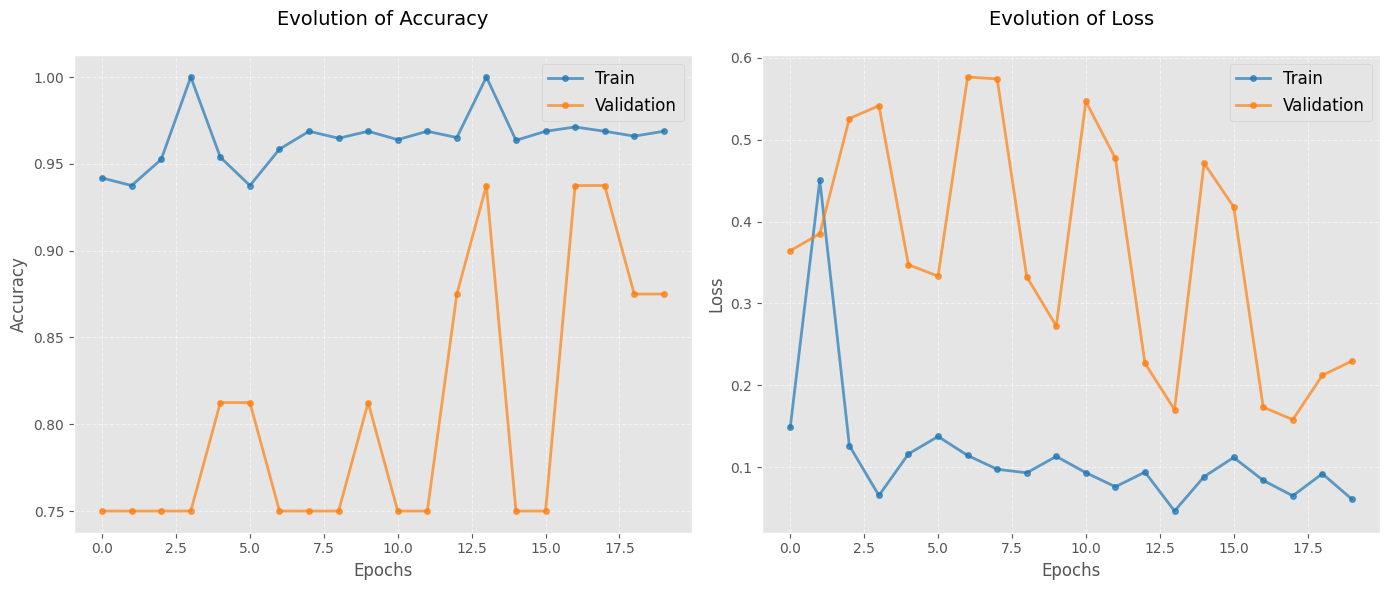

Training curves saved to: C:\Users\user\Pneumonia_Detection\notebook\results\training_curves.png


In [38]:
plt.style.use("ggplot")

plot_kwargs = {"linewidth": 2, "marker": "o", "markersize": 4, "alpha": 0.7}

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train", color="#1f77b4", **plot_kwargs)
plt.plot(history.history["val_accuracy"], label="Validation", color="#ff7f0e", **plot_kwargs)
plt.title("Evolution of Accuracy\n", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train", color="#1f77b4", **plot_kwargs)
plt.plot(history.history["val_loss"], label="Validation", color="#ff7f0e", **plot_kwargs)
plt.title("Evolution of Loss\n", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
curves_path = RESULTS_DIR / "training_curves.png"
plt.savefig(curves_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Training curves saved to: {curves_path}")

In [39]:
print("Expected input shape:", model_02.input_shape)
print("Class indices:", train_generator.class_indices)

Expected input shape: (None, 128, 128, 3)
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
classes = ['NORMAL', 'PNEUMONIA']

correct = 0
total = 0
y_true = []
y_pred = []

for class_idx, class_name in enumerate(classes):
    class_path = TEST_DIR / class_name
    
    if not class_path.exists():
        print(f"Dossier manquant : {class_path}")
        continue

    image_files = list(class_path.glob("*.*"))
    print(f"{class_name}: {len(image_files)} images")

    for img_path in image_files:
        try:
            img = image.load_img(img_path, target_size=(128, 128))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0

            prediction = model_02.predict(img_array, verbose=0)
            predicted_class = np.argmax(prediction)

            y_true.append(class_idx)
            y_pred.append(predicted_class)

            if predicted_class == class_idx:
                correct += 1
            total += 1

        except Exception as e:
            print(f"Erreur avec {img_path.name}: {e}")

if total > 0:
    print(f"\nAccuracy globale : {correct / total:.4f}")
    print("\nMatrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification report :")
    print(classification_report(y_true, y_pred, target_names=classes))
else:
    print("Aucune image test trouvée.")

NORMAL: 234 images
PNEUMONIA: 250 images

Accuracy globale : 0.7583

Matrice de confusion :
[[132 102]
 [ 15 235]]

Classification report :
              precision    recall  f1-score   support

      NORMAL       0.90      0.56      0.69       234
   PNEUMONIA       0.70      0.94      0.80       250

    accuracy                           0.76       484
   macro avg       0.80      0.75      0.75       484
weighted avg       0.79      0.76      0.75       484

